# Questions


Total marks: 20 <br>

1. Load the Iris dataset from scikit-learn: https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html
 (1/20) <br>
2. Preprocess the dataset as required, i.e. feature scaling or standardization (1/20)
<br>
3. Encode the class labels as one-hot vectors.   (1/20)
<br>
4. Show the class distribution of the dataset using a bar graph. Is the dataset balanced? (1/20)
<br>
5. Split the data into training, validation, and test sets (70%-15%-15%).  (1/20)
<br>
6. Implement a softmax (multinomial) logistic regression model from scratch.  (1/20)
<br>
7. Using cross entropy as loss and apply L2 regularization to the weights in the cost function and train the softmax logistic regression model with gradient descent. Use cross validation to find a suitable value of the learning rate and regularization parameter. Also give the training and validation loss vs. training epochs plot. (6/20)
<br>
8. Report the prediction performance of your implementation on the test set in terms of confusion matrix, precision, recall and area under precision recall curve.  (2/20)
<br>
9. Fit a logistic regression model using scikit-learn's Logistic Regression model https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html. Use multi-class=’multinomial’ and penalty =’l2’ and the parameter C to be equal to the inverse of the regularization parameter that you found through cross validation. (4/20)
<br>
10. Compare the performance of your custom logistic regression model with scikit learn in terms of accuracy, precision, recall and area under precision-recall curve. (2/20)

# Range of values for learning rate and regularization strength
learning_rates = np.logspace(-3, -1, 5) <br>
reg_lambdas = np.logspace(-4, -1, 4)

# Solutions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    average_precision_score,
    PrecisionRecallDisplay,
)
from sklearn.linear_model import LogisticRegression
import seaborn as sns


load dataset

In [ ]:
iris = datasets.load_iris()
X_raw = iris.data
y_raw = iris.target

preprocess the dataset

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

one-hot encoding

In [ ]:
ohe = OneHotEncoder()
Y_onehot = ohe.fit_transform(y_raw.reshape(-1, 1))

In [ ]:
Y_onehot

<150x3 sparse matrix of type '<class 'numpy.float64'>'
	with 150 stored elements in Compressed Sparse Row format>

In [ ]:
def to_dense(mat):
    return mat.toarray() if hasattr(mat, "toarray") else mat  # handle sparse or dense

In [ ]:
Y_onehot = to_dense(Y_onehot)

Plot class distribution

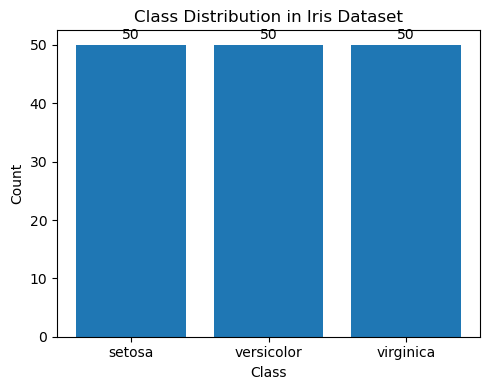

In [ ]:
unique, counts = np.unique(y_raw, return_counts=True)
plt.figure(figsize=(5, 4))
plt.bar(iris.target_names[unique], counts)
plt.title("Class Distribution in Iris Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
for i, c in enumerate(counts):
    plt.text(i, c + 1, str(c), ha="center")
plt.tight_layout()
plt.show()

Data split

In [ ]:
# Split into train/validation/test (70%-15%-15%) stratified to preserve class balance
X_temp, X_test, y_temp, y_test, Y_temp_onehot, Y_test_onehot = train_test_split(
    X, y_raw, Y_onehot, test_size=0.15, stratify=y_raw, random_state=42
)
# Now split X_temp into train (70/85 ≈ 0.8235) and validation (15/85 ≈ 0.1765) so final is 70/15/15
val_frac_of_temp = 0.15 / (1 - 0.15)
X_train, X_val, y_train, y_val, Y_train_onehot, Y_val_onehot = train_test_split(
    X_temp, y_temp, Y_temp_onehot, test_size=val_frac_of_temp, stratify=y_temp, random_state=42
)

In [ ]:
print(f"Train/Val/Test sizes: {X_train.shape[0]}, {X_val.shape[0]}, {X_test.shape[0]}")

Train/Val/Test sizes: 104, 23, 23


Helper functions for logistic regression from scratch

In [ ]:
def softmax(z):
    # For numerical stability, subtract the maximum value from each input vector
    # This prevents overflow when calculating exp(x)
    z = z - np.max(z, axis=1, keepdims=True) #numerical stability
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)


def compute_loss(X, Y_onehot, W, reg_lambda):
    """
    Cross-entropy loss with L2 regularization (excluding bias term).
    X: (n_samples, n_features+1) with bias augmented
    Y_onehot: (n_samples, n_classes)
    W: (n_features+1, n_classes)
    """
    n = X.shape[0]
    logits = X @ W  # (n, C)
    probs = softmax(logits)
    # Clip for numerical stability
    eps = 1e-12
    loss_ce = -np.sum(Y_onehot * np.log(probs + eps)) / n
    # L2 regularization, exclude bias (assume last row is bias if bias appended)
    W_no_bias = W[:-1, :]  # assuming bias is last row
    l2 = 0.5 * reg_lambda * np.sum(W_no_bias ** 2)
    return loss_ce + l2


def compute_gradient(X, Y_onehot, W, reg_lambda):
    n = X.shape[0]
    logits = X @ W
    probs = softmax(logits)  # (n, C)
    grad = (X.T @ (probs - Y_onehot)) / n  # (d+1, C)
    # add regularization for weights excluding bias
    reg = np.zeros_like(W)
    reg[:-1, :] = reg_lambda * W[:-1, :]
    return grad + reg  # shape (d+1, C)


def train_custom_logistic(
    X_train,
    Y_train_onehot,
    X_val,
    Y_val_onehot,
    learning_rate,
    reg_lambda,
    epochs=500,
    tol=1e-6,
    verbose=False,
):
    """
    Trains softmax logistic regression with gradient descent.
    Returns learned weights and history of losses.
    """
    n_samples, n_features = X_train.shape
    n_classes = Y_train_onehot.shape[1]
    # augment bias by adding column of ones
    X_train_aug = np.hstack([X_train, np.ones((X_train.shape[0], 1))])  # bias last
    X_val_aug = np.hstack([X_val, np.ones((X_val.shape[0], 1))])

    # initialize W small
    rng = np.random.default_rng(42)
    W = rng.normal(0, 0.01, size=(n_features + 1, n_classes))  # (d+1, C)

    best_val_loss = np.inf
    patience = 30
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        grad = compute_gradient(X_train_aug, Y_train_onehot, W, reg_lambda)
        W -= learning_rate * grad

        train_loss = compute_loss(X_train_aug, Y_train_onehot, W, reg_lambda)
        val_loss = compute_loss(X_val_aug, Y_val_onehot, W, reg_lambda)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose and epoch % 50 == 0:
            print(f"[Epoch {epoch}] train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

        # early stopping based on validation loss
        if val_loss + tol < best_val_loss:
            best_val_loss = val_loss
            best_W = W.copy()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    return best_W, history


def predict_proba_custom(X, W):
    X_aug = np.hstack([X, np.ones((X.shape[0], 1))])
    logits = X_aug @ W
    return softmax(logits)


def predict_custom(X, W):
    probs = predict_proba_custom(X, W)
    return np.argmax(probs, axis=1)

Grid search for tuning of hyperparameters

In [ ]:
learning_rates = np.logspace(-3, -1, 5)
reg_lambdas = np.logspace(-4, -1, 4)

# Use 5-fold CV on the training set to pick hyperparameters
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_score = -np.inf
best_params = None
for lr in learning_rates:
    for reg in reg_lambdas:
        fold_scores = []
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr_fold = X_train[train_idx]
            y_tr_fold = y_train[train_idx]
            Y_tr_fold_ohe = Y_train_onehot[train_idx]
            X_val_fold = X_train[val_idx]
            y_val_fold = y_train[val_idx]
            Y_val_fold_ohe = Y_train_onehot[val_idx]

            W_fold, _ = train_custom_logistic(
                X_tr_fold, Y_tr_fold_ohe, X_val_fold, Y_val_fold_ohe,
                learning_rate=lr,
                reg_lambda=reg,
                epochs=1000,
                tol=1e-6,
                verbose=False,
            )
            # Evaluate on this fold's validation: use average precision macro
            proba_val = predict_proba_custom(X_val_fold, W_fold)
            ap = average_precision_score(
                Y_val_fold_ohe, proba_val, average="macro"
            )
            fold_scores.append(ap)

        mean_ap = np.mean(fold_scores)
        if mean_ap > best_score:
            best_score = mean_ap
            best_params = {"learning_rate": lr, "reg_lambda": reg}

print("Best hyperparameters from CV:", best_params, "with mean AP:", best_score)


Best hyperparameters from CV: {'learning_rate': 0.1, 'reg_lambda': 0.0001} with mean AP: 0.993004535147392


In [ ]:
# Retrain on full training set (optionally could combine train+val for final model)
W_final, history = train_custom_logistic(
    X_train,
    Y_train_onehot,
    X_val,
    Y_val_onehot,
    learning_rate=best_params["learning_rate"],
    reg_lambda=best_params["reg_lambda"],
    epochs=3000,
    tol=1e-6,
    verbose=True,
)


[Epoch 0] train_loss=0.9919 val_loss=0.9920
[Epoch 50] train_loss=0.3897 val_loss=0.3922
[Epoch 100] train_loss=0.3218 val_loss=0.3167
[Epoch 150] train_loss=0.2838 val_loss=0.2726
[Epoch 200] train_loss=0.2567 val_loss=0.2408
[Epoch 250] train_loss=0.2357 val_loss=0.2161
[Epoch 300] train_loss=0.2188 val_loss=0.1963
[Epoch 350] train_loss=0.2048 val_loss=0.1801
[Epoch 400] train_loss=0.1931 val_loss=0.1665
[Epoch 450] train_loss=0.1831 val_loss=0.1549
[Epoch 500] train_loss=0.1745 val_loss=0.1450
[Epoch 550] train_loss=0.1670 val_loss=0.1364
[Epoch 600] train_loss=0.1604 val_loss=0.1289
[Epoch 650] train_loss=0.1545 val_loss=0.1223
[Epoch 700] train_loss=0.1493 val_loss=0.1164
[Epoch 750] train_loss=0.1446 val_loss=0.1111
[Epoch 800] train_loss=0.1404 val_loss=0.1064
[Epoch 850] train_loss=0.1366 val_loss=0.1021
[Epoch 900] train_loss=0.1331 val_loss=0.0982
[Epoch 950] train_loss=0.1299 val_loss=0.0947
[Epoch 1000] train_loss=0.1270 val_loss=0.0914
[Epoch 1050] train_loss=0.1243 val_l

In [ ]:
# plotting utility
def plot_loss_curve(history, title="Training vs Validation Loss"):
    """
    history: dict with keys 'train_loss' and 'val_loss' (lists)
    """
    train = np.array(history["train_loss"])
    val = np.array(history["val_loss"])
    train_plot = train
    val_plot = val

    plt.figure(figsize=(6, 4))
    plt.plot(train_plot, label="Train Loss", linewidth=1.5)
    plt.plot(val_plot, label="Validation Loss", linewidth=1.5)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()


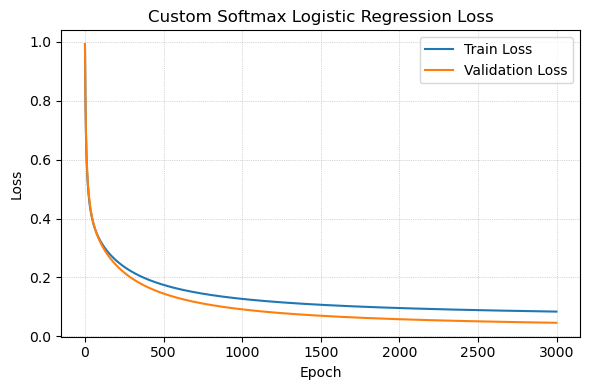

In [ ]:
# plot the loss curves
plot_loss_curve(history, title="Custom Softmax Logistic Regression Loss")

In [ ]:
# Evaluation on test set for custom model
y_pred_custom = predict_custom(X_test, W_final)
proba_custom = predict_proba_custom(X_test, W_final)


In [ ]:
print("\nCustom Softmax Logistic Regression Metrics on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision (macro):", precision_score(y_test, y_pred_custom, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred_custom, average="macro", zero_division=0))
ap_custom = average_precision_score(Y_test_onehot, proba_custom, average="macro")
print("Average Precision (macro, area under PR):", ap_custom)


Custom Softmax Logistic Regression Metrics on Test Set:
Accuracy: 0.9565217391304348
Precision (macro): 0.9629629629629629
Recall (macro): 0.9583333333333334
Average Precision (macro, area under PR): 1.0


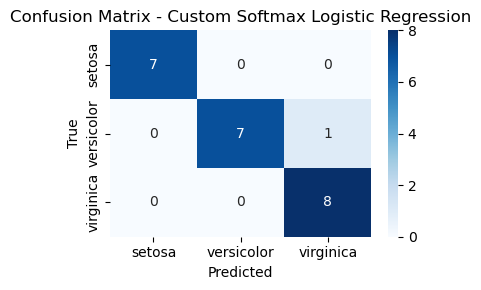

In [ ]:
# Confusion matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm_custom,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cmap="Blues",
)
plt.title("Confusion Matrix - Custom Softmax Logistic Regression")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


Implementation of logistic regression via scikit-learn

In [ ]:
C_value = 1.0 / best_params["reg_lambda"]  # inverse of regularization strength - done to match the regularization strength of the custom implementation done above
sklearn_model = LogisticRegression(
    multi_class="multinomial",
    penalty="l2",
    C=C_value,
    solver="lbfgs",
    max_iter=500,
    random_state=42,
)
sklearn_model.fit(X_train, y_train)

y_pred_skl = sklearn_model.predict(X_test)
proba_skl = sklearn_model.predict_proba(X_test)


In [ ]:
print("\nscikit-learn Logistic Regression Metrics on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_skl))
print("Precision (macro):", precision_score(y_test, y_pred_skl, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred_skl, average="macro", zero_division=0))
ap_skl = average_precision_score(Y_test_onehot, proba_skl, average="macro")
print("Average Precision (macro, area under PR):", ap_skl)


scikit-learn Logistic Regression Metrics on Test Set:
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
Average Precision (macro, area under PR): 1.0


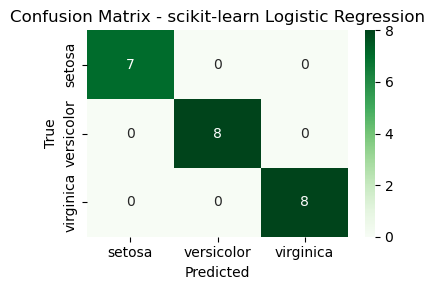

In [ ]:
# Confusion matrix - sklearn
cm_skl = confusion_matrix(y_test, y_pred_skl)
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm_skl,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cmap="Greens",
)
plt.title("Confusion Matrix - scikit-learn Logistic Regression")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()